In [1]:
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

base_yaml_path = Path("../config/base.yaml").resolve()

with base_yaml_path.open() as f:
    base = yaml.safe_load(f)

project_root = base_yaml_path.parent.parent

transcriptomics_path = (project_root / base["paths"]["raw_transcriptomics"]).resolve()
metabolomics_path = (project_root / base["paths"]["raw_metabolomics"]).resolve()

output_path = Path("outputs/figures").mkdir(parents=True, exist_ok=True)

## Transcriptomics

In [2]:
transcriptomics = pd.read_csv(transcriptomics_path, index_col=0)
transcriptomics.index.name = "DepMap_ID"

transcriptomics.columns = transcriptomics.columns.str.replace(r"\s*\(\d+\)\s*", "", regex=True)

print("\nTranscriptomics shape:", transcriptomics.shape)

total_cells = transcriptomics.shape[0] * transcriptomics.shape[1]
nans = transcriptomics.isna().sum().sum()

print("NaNs:", nans, f"({100 * nans / total_cells:.4f}%)")

dup = transcriptomics.columns.duplicated().sum()
print("Duplicate columns:", dup)
if dup:
    print("Duplicated names:", transcriptomics.columns[transcriptomics.columns.duplicated()].tolist())


Transcriptomics shape: (1684, 19205)
NaNs: 0 (0.0000%)
Duplicate columns: 0


In [3]:
gene_mean = transcriptomics.mean()
gene_var = transcriptomics.var()
zero_frac = (transcriptomics == 0).mean()

print("\nGene mean summary")
print(gene_mean.describe())

print("\nGene variance summary")
print(gene_var.describe())

print("\nGene sparsity (zero fraction)")
print(zero_frac.describe())


Gene mean summary
count    19205.000000
mean         2.673606
std          2.320543
min          0.000000
25%          0.423179
50%          2.411464
75%          4.388964
max         14.297443
dtype: float64

Gene variance summary
count    19205.000000
mean         1.114353
std          1.436193
min          0.000000
25%          0.365504
50%          0.614732
75%          1.315239
max         17.984264
dtype: float64

Gene sparsity (zero fraction)
count    19205.000000
mean         0.174432
std          0.291243
min          0.000000
25%          0.000000
50%          0.004751
75%          0.226247
max          1.000000
dtype: float64


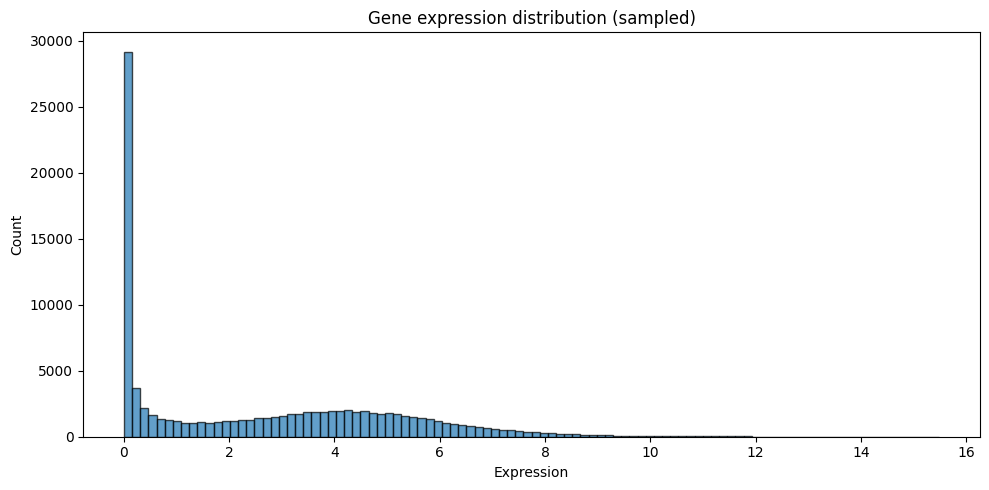

In [4]:
values = transcriptomics.to_numpy().ravel()
values = values[~np.isnan(values)]

sample = np.random.choice(values, min(100_000, len(values)), replace=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sample, bins=100, edgecolor="black", alpha=0.7)
ax.set(xlabel="Expression", ylabel="Count")
ax.set_title("Gene expression distribution (sampled)")
plt.tight_layout()
plt.show()


Sample total signal
count     1684.000000
mean     51346.598785
std       3731.114167
min      23612.268658
25%      49402.746873
50%      51796.500513
75%      53663.395342
max      62362.335562
dtype: float64


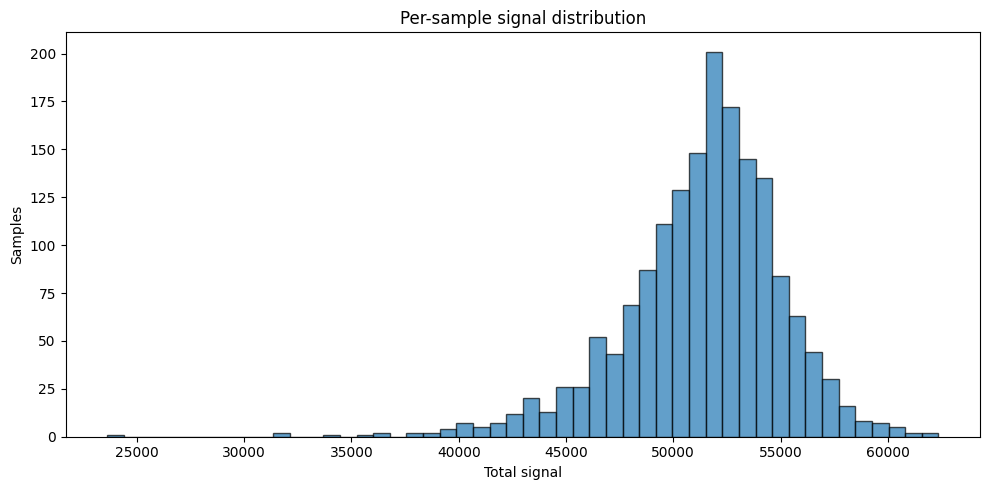

In [5]:
sample_signal = transcriptomics.sum(axis=1)

print("\nSample total signal")
print(sample_signal.describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sample_signal, bins=50, edgecolor="black", alpha=0.7)
ax.set(xlabel="Total signal", ylabel="Samples")
ax.set_title("Per-sample signal distribution")
plt.tight_layout()
plt.show()

## Metabolomics

In [6]:
metabolomics = pd.read_csv(metabolomics_path)
metabolomics = metabolomics.set_index("DepMap_ID")
metabolomics = metabolomics.apply(pd.to_numeric, errors="coerce")
metabolomics = metabolomics.drop(columns=["CCLE_ID"])

print("\nMetabolomics shape:", metabolomics.shape)

total_cells = metabolomics.shape[0] * metabolomics.shape[1]
missing = metabolomics.isna().sum().sum()

print("Missing:", missing, f"({100 * missing / total_cells:.4f}%)")

zeros = (metabolomics == 0).sum().sum()
print("Zeros:", zeros, f"({100 * zeros / total_cells:.4f}%)")

non_zero = metabolomics[(metabolomics > 0) & (metabolomics.notna())].values.ravel()
if len(non_zero):
    print("Min non-zero:", non_zero.min())
    print("Max value:", metabolomics.values.max())


Metabolomics shape: (928, 225)
Missing: 0 (0.0000%)
Zeros: 0 (0.0000%)
Min non-zero: 2.9760308
Max value: 9.0989016


In [7]:
met_mean = metabolomics.mean()
met_var = metabolomics.var()

zero_frac = (metabolomics == 0).sum(axis=0) / metabolomics.notna().sum(axis=0)

print("\nMetabolite mean summary")
print(met_mean.describe())

print("\nMetabolite variance summary")
print(met_var.describe())

print("\nMetabolite sparsity")
print(zero_frac.describe())


Metabolite mean summary
count    225.000000
mean       5.876960
std        0.068995
min        5.548040
25%        5.837869
50%        5.890189
75%        5.919457
max        6.020252
dtype: float64

Metabolite variance summary
count    225.000000
mean       0.157143
std        0.153824
min        0.023500
25%        0.083198
50%        0.126154
75%        0.181304
max        1.814259
dtype: float64

Metabolite sparsity
count    225.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
dtype: float64


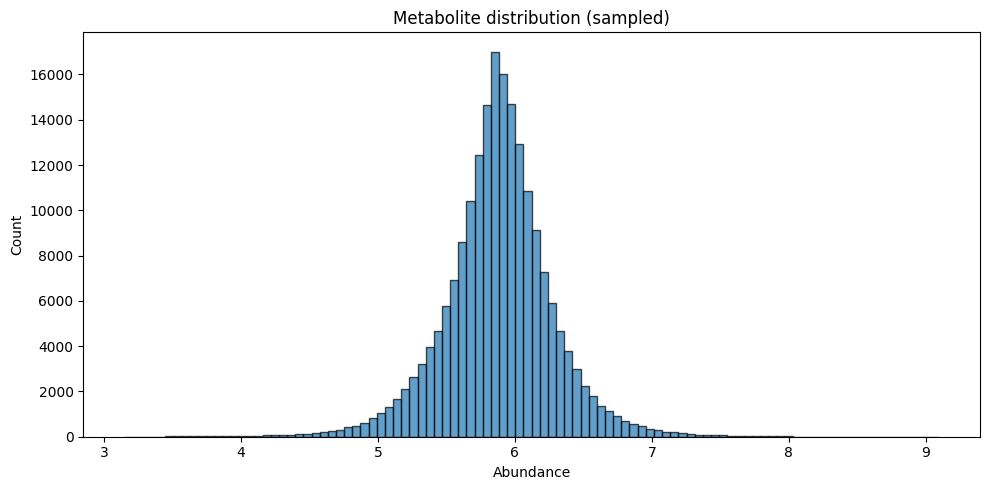

In [8]:
values = metabolomics.to_numpy().ravel()
values = values[~np.isnan(values)]

sample = np.random.choice(values, min(200000, len(values)), replace=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sample, bins=100, edgecolor="black", alpha=0.7)
ax.set(xlabel="Abundance", ylabel="Count")
ax.set_title("Metabolite distribution (sampled)")
plt.tight_layout()
plt.show()


Sample-level statistics
count     928.000000
mean     1322.316102
std         7.407805
min      1284.664073
25%      1318.264104
50%      1322.940682
75%      1326.979710
max      1347.563019
dtype: float64


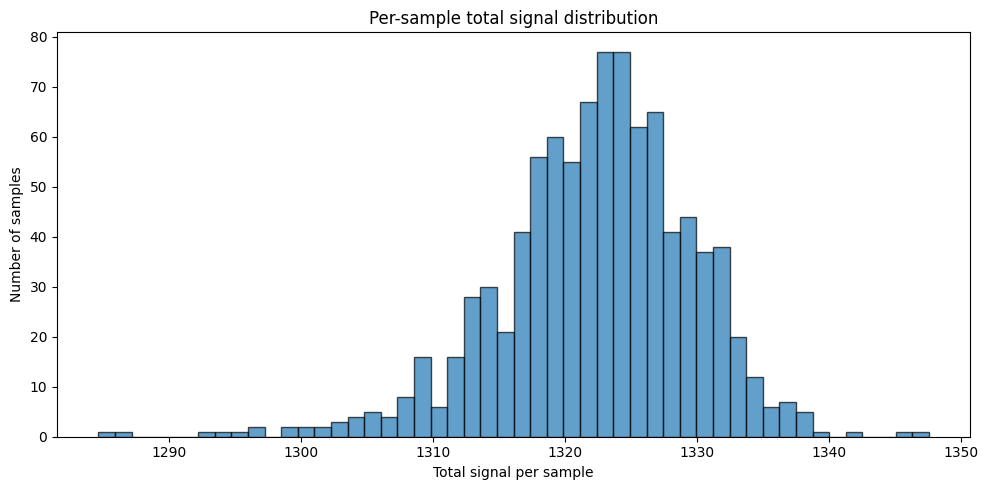

In [9]:
sample_total_signal = metabolomics.sum(axis=1)

print("\nSample-level statistics")
print(sample_total_signal.describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sample_total_signal, bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Total signal per sample")
ax.set_ylabel("Number of samples")
ax.set_title("Per-sample total signal distribution")
plt.tight_layout()
plt.show()

## Paired


Paired samples: 912 (expected 912)
Cross-omics Pearson r: 0.0446


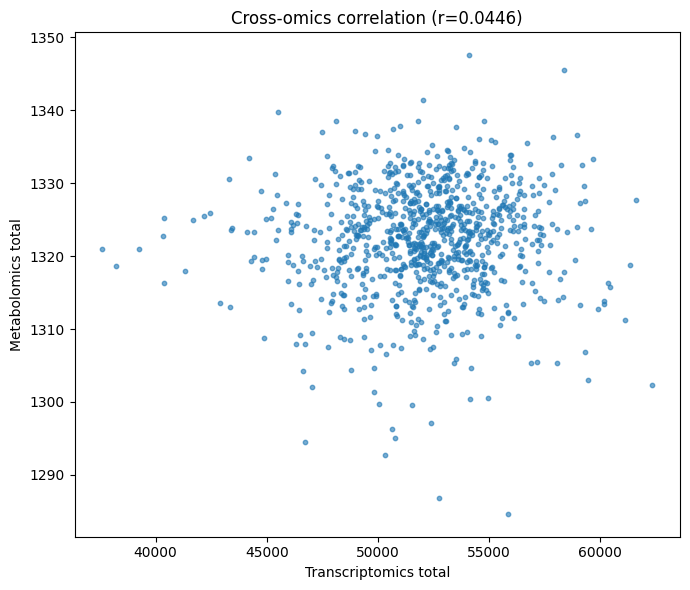

In [10]:
common = transcriptomics.index.intersection(metabolomics.index)

tx = transcriptomics.loc[common]
mt = metabolomics.loc[common]

print("\nPaired samples:", len(common), "(expected 912)")

tx_total = tx.sum(axis=1)
mt_total = mt.sum(axis=1)

corr = tx_total.corr(mt_total)

print("Cross-omics Pearson r:", round(corr, 4))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(tx_total, mt_total, s=10, alpha=0.6)
ax.set(xlabel="Transcriptomics total", ylabel="Metabolomics total")
ax.set_title(f"Cross-omics correlation (r={corr:.4f})")
plt.tight_layout()
plt.show()

In [ ]:
output_dir = Path("outputs/figures")
output_dir.mkdir(parents=True, exist_ok=True)

figure_names = {
    1: "tx_expression_hist",
    2: "tx_sample_total_signal",
    3: "meta_value_hist",
    4: "meta_sample_total_signal",
    5: "cross_omics_corr"

}

print("Saving figures")
for num in plt.get_fignums():
    fig = plt.figure(num)
    name = figure_names.get(num, f"figure_{num:02d}")
    path = output_dir / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path.name)

print("Done:", output_dir.resolve())


Saving figures
Done: /home/godfather/Personal_Projects/AI-Bioinformatics-Projects/joint_multi_omics_vae/notebooks/outputs/figures
